In [1]:
import pandas as pd

In [5]:
orderlines_df = pd.read_csv("../Data/not_cleaned/orderlines.csv")



In [6]:
orderlines_df.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38


In [7]:
orderlines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                293983 non-null  int64
 1   id_order          293983 non-null  int64
 2   product_id        293983 non-null  int64
 3   product_quantity  293983 non-null  int64
 4   sku               293983 non-null  str  
 5   unit_price        293983 non-null  str  
 6   date              293983 non-null  str  
dtypes: int64(4), str(3)
memory usage: 15.7 MB


In [10]:
orderlines= pd.read_csv("../Data/not_cleaned/orderlines.csv")

orderlines_df= orderlines.copy()

In [11]:
orders = pd.read_csv("../Data/not_cleaned/orders.csv")

orders_df= orders.copy()

In [12]:
products = pd.read_csv("../Data/not_cleaned/products.csv")

products_df= products.copy()

# Orders Table
226909 rows × 4 columns
No Duplicates
total_paid - 5 missing values - to drop?
created_date convert to datetime series

In [13]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  str    
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 6.9 MB


In [14]:
orders_df.duplicated().sum()

np.int64(0)

In [15]:
orders_df.isnull().sum()
# total_paid has 5 missing values

order_id        0
created_date    0
total_paid      5
state           0
dtype: int64

In [16]:
orders_df["total_paid"].isnull().mean()*100
# Only .22% of data is missing, hence deleting these rows

np.float64(0.0022035265238487677)

In [17]:
orders_df.dropna(subset=["total_paid"], inplace = True)

In [18]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

In [19]:
orders_df.info()

<class 'pandas.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[us]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 8.7 MB


# Orderlines Table

No duplicates
product_id - value is 0, so drop column
product_quantity - 
• 10 rows with quantity > 100 - flagged to review
• Example: 192 units of APP1662 at €519 each = €99,648 in a single orderline
date - convert to datetime series
sku - brand code has lower case par0072(12 times). Convert sku column to uppercase
unit_price - 12% double decimal data. to drop or Regex?
unit_price to numeric conversion

In [20]:
orderlines_df.duplicated().sum()
# No duplicates

np.int64(0)

In [21]:
orderlines_df.isnull().sum()
# No null values

id                  0
id_order            0
product_id          0
product_quantity    0
sku                 0
unit_price          0
date                0
dtype: int64

In [22]:
orderlines_df.info()
# unit_price str to num
# date str to datetime series

<class 'pandas.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                293983 non-null  int64
 1   id_order          293983 non-null  int64
 2   product_id        293983 non-null  int64
 3   product_quantity  293983 non-null  int64
 4   sku               293983 non-null  str  
 5   unit_price        293983 non-null  str  
 6   date              293983 non-null  str  
dtypes: int64(4), str(3)
memory usage: 15.7 MB


In [23]:
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

In [24]:
orderlines_df["date"].dtype

dtype('<M8[us]')

In [25]:
up_error = orderlines_df.loc[
    (orderlines_df.unit_price.str.contains(r"\d+\.\d+\.\d+")) |
    (orderlines_df.unit_price.str.contains(r"\d+\.\d{3,}")), :].shape[0]

In [26]:
up_error/orderlines_df.shape[0]*100

12.30309235568043

In [27]:
up_errorlist = orderlines_df.loc[
    (orderlines_df.unit_price.str.contains(r"\d+\.\d+\.\d+")) |
    (orderlines_df.unit_price.str.contains(r"\d+\.\d{3,}")), "id_order"]
orderlines_df = orderlines_df.loc[~orderlines_df.id_order.isin(up_errorlist)]

In [28]:
orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"] )

In [29]:
orderlines_df.info()

<class 'pandas.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  str           
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 13.2 MB


In [30]:
orderlines_df.describe()

,id,id_order,product_id,product_quantity,unit_price,date
count,2.162500e+05,216250.000000,216250.0,216250.000000,216250.000000,216250
mean,1.372496e+06,408967.391727,0.0,1.136698,164.636160,2017-08-29 19:05:38.143486
min,1.119109e+06,241319.000000,0.0,1.000000,-119.000000,2017-01-01 00:07:19
25%,1.240903e+06,351866.250000,0.0,1.000000,29.740000,2017-05-03 17:36:03.250000
50%,1.366966e+06,406548.500000,0.0,1.000000,69.990000,2017-10-02 04:13:04.500000
75%,1.503947e+06,465795.500000,0.0,1.000000,184.580000,2017-12-18 23:35:52.250000
max,1.650203e+06,527401.000000,0.0,999.000000,999.990000,2018-03-14 13:58:36
std,1.517563e+05,65892.054168,0.0,3.292203,219.630604,NaN


In [ ]:
# Products Table

8746 duplicate values - drop duplicates
desc - 7 missing, fill with name description
price - 46 missing and 596 decimal prob - to drop or Regex?
price - to numeric conversion
promo_price decimal value issue. also promo price is higher than price - to drop?
type - string and has scientific notation, no use

## Duplicates Check

In [31]:
products_df.duplicated().sum()

np.int64(8746)

In [32]:
products_df.loc[products_df.duplicated(keep=False),:].sort_values("sku", ascending = False)
# Checking the duplicate rows

,sku,name,desc,price,promo_price,in_stock,type
12723,WDT0317,WD My Cloud EX2 Ultra Mac and PC Server NAS,2-bay NAS 1GB RAM for Mac and PC,169.99,1.391.899,0,11935397
12724,WDT0317,WD My Cloud EX2 Ultra Mac and PC Server NAS,2-bay NAS 1GB RAM for Mac and PC,169.99,1.391.899,0,11935397
12716,WDT0311-A,Open - WD My Cloud EX2 Ultra Mac and PC Server...,2-bay NAS 1GB RAM for Mac and PC,169.99,1.325.138,1,11935397
12715,WDT0311-A,Open - WD My Cloud EX2 Ultra Mac and PC Server...,2-bay NAS 1GB RAM for Mac and PC,169.99,1.325.138,1,11935397
12714,WDT0311-A,Open - WD My Cloud EX2 Ultra Mac and PC Server...,2-bay NAS 1GB RAM for Mac and PC,169.99,1.325.138,1,11935397
...,...,...,...,...,...,...,...
107,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
108,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
101,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
1902,AII0013,"Aiino Case MacBook Air 13 ""Transparent",MacBook Air 13-inch casing with matte finish.,39.99,179.927,0,13835403


In [33]:
products_df.drop_duplicates(inplace= True)

In [34]:
products_df["sku"].duplicated().sum()
# 'sku' is unique identifier so checking for duplicates

np.int64(1)

In [35]:
products_df.loc[products_df["sku"].duplicated(keep=False)]

,sku,name,desc,price,promo_price,in_stock,type
7992,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,1729,1305.59,0,1282
8000,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,NaN,1305.59,0,1282


In [36]:
products_df = products_df.drop(8000)
# deleting the duplicate value by drop(index)

## Missing Values

In [37]:
products_df.isnull().sum()

sku             0
name            0
desc            7
price          45
promo_price     0
in_stock        0
type           50
dtype: int64

In [38]:
products_df.loc[products_df['desc'].isna(), :]

,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


In [39]:
products_df.loc[products_df['desc'].isna(), 'desc'] = products_df.loc[products_df['desc'].isna(), 'name']
# using the name column to fill the description

In [40]:
products_df.loc[products_df['desc'].isna(), :]

,sku,name,desc,price,promo_price,in_stock,type


In [41]:
products_df["price"].isnull().mean()*100

np.float64(0.4253710180546365)

In [42]:
products_df = products_df.dropna(subset=['price'])

In [43]:
products_df.info()

<class 'pandas.DataFrame'>
Index: 10534 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          10534 non-null  str  
 1   name         10534 non-null  str  
 2   desc         10534 non-null  str  
 3   price        10534 non-null  str  
 4   promo_price  10534 non-null  str  
 5   in_stock     10534 non-null  int64
 6   type         10484 non-null  str  
dtypes: int64(1), str(6)
memory usage: 658.4 KB


In [44]:
price_problems_number = products_df.loc[
    (products_df.price.str.contains(r"\d+\.\d+\.\d+"))|(products_df.price.str.contains(r"\d+\.\d{3,}")), :].shape[0]
price_problems_number
# 5.15% of the rows of the DataFrame

542

Price is critical for accurate discount analysis, and this data will inform business decisions — so we're prioritizing trustworthiness over row retention. Deleting the malformed price rows.

In [45]:
products_df = products_df.loc[~((products_df.price.str.contains(r"\d+\.\d+\.\d+"))|
                                (products_df.price.str.contains(r"\d+\.\d{3,}"))), :]

In [46]:
products_df["price"] = pd.to_numeric(products_df["price"])

In [47]:
promo_problems_number = products_df.loc[(products_df.promo_price.str.contains(r"\d+\.\d+\.\d+"))|(products_df.promo_price.str.contains(r"\d+\.\d{3,}")), :].shape[0]
promo_problems_number

9232

In [48]:
round(((promo_problems_number / products_df.shape[0]) * 100), 2)
# promo_price has in total 9232 wrong values. This is 92.39% of the rows of the DataFrame
# This column appears to be very untrustworthy, we will delete the column.

92.39

In [49]:
products_cl = products_df.drop(columns=["promo_price"])

In [50]:
products_df.info()

<class 'pandas.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          9992 non-null   str    
 1   name         9992 non-null   str    
 2   desc         9992 non-null   str    
 3   price        9992 non-null   float64
 4   promo_price  9992 non-null   str    
 5   in_stock     9992 non-null   int64  
 6   type         9946 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 624.5 KB


In [51]:
orders_df.info()

<class 'pandas.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[us]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 8.7 MB


In [52]:
orderlines_df.info()

<class 'pandas.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  str           
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 13.2 MB


In [53]:
brands = pd.read_csv("../Data/not_cleaned/brands.csv")

brands_df= brands.copy()

In [54]:
brands_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   short   187 non-null    str  
 1   long    187 non-null    str  
dtypes: str(2)
memory usage: 3.1 KB


In [ ]:
# Clean Dataset

In [55]:
orders_cl = orders_df.copy()
orderlines_cl = orderlines_df.copy()
products_cl = products_df.copy()
brands_cl = brands_df.copy()

In [56]:
orders_cl.to_csv("orders_cl.csv", index=False)
orderlines_cl.to_csv("orderlines_cl.csv", index=False)
products_cl.to_csv("products_cl.csv", index=False)
brands_cl.to_csv("brands_cl.csv", index=False)

#Load Cleaned Data

In [57]:
orders_cl = pd.read_csv("orders_cl.csv")
orderlines_cl = pd.read_csv("orderlines_cl.csv")
products_cl = pd.read_csv("products_cl.csv")
brands_cl = pd.read_csv("brands_cl.csv")

In [58]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

## 1.&nbsp; Define Pandas display format

In [59]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [60]:
orders_qu.shape

(226904, 4)

In [61]:
orders_qu["state"].value_counts()

state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14374
Cancelled            7233
Name: count, dtype: int64

In [62]:
orders_qu = orders_qu.loc[(orders_qu["state"] == "Completed")]
# 20% of the data is retained

In [63]:
orders_qu["state"].value_counts()

state
Completed    46605
Name: count, dtype: int64

In [71]:
46605/226904 * 100

20.53952332263865

In [64]:
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(orders_qu["order_id"]), :]

In [65]:
orderlines_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 216250 entries, 0 to 216249
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                216250 non-null  int64  
 1   id_order          216250 non-null  int64  
 2   product_id        216250 non-null  int64  
 3   product_quantity  216250 non-null  int64  
 4   sku               216250 non-null  str    
 5   unit_price        216250 non-null  float64
 6   date              216250 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 11.5 MB


In [66]:
orderlines_qu.shape[0]

56714

In [67]:
orderlines_cl.shape

(216250, 7)

In [68]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(orderlines_qu["id_order"])]
# order with no item line in orderline df filtered - to check ripple effect

In [69]:
orders_qu.shape

(43064, 4)

## 3.&nbsp; Exclude orders with unknown products

In [72]:
orderlines_products = orderlines_qu.merge(products_qu, how="left", on = "sku")[["id_order","sku","name" ]]

In [73]:
orderlines_products.name.isna().value_counts()

name
False    55320
True      1394
Name: count, dtype: int64

In [74]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363], shape=(1363,))

In [75]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete),:]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete),:]

In [76]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(41701, 41701)

In [77]:
orders_qu_copy = orders_qu.copy()

In [78]:
orderlines_qu_copy = orderlines_qu.copy()

In [79]:
orderlines_qu_copy["unit_price_total"] = orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]
orderlines_qu_copy

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
6,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
7,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
8,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,72.19
15,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
21,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...,...,...
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [81]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()

In [82]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()

In [83]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


In [84]:
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")
diff_df

,order_id,created_date,total_paid,state,id_order,unit_price_total
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98
...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97


In [85]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]

In [86]:
diff_df.difference.mean().round(2)

np.float64(4.47)

In [ ]:
### What is the distribution of these differences?

<Axes: >

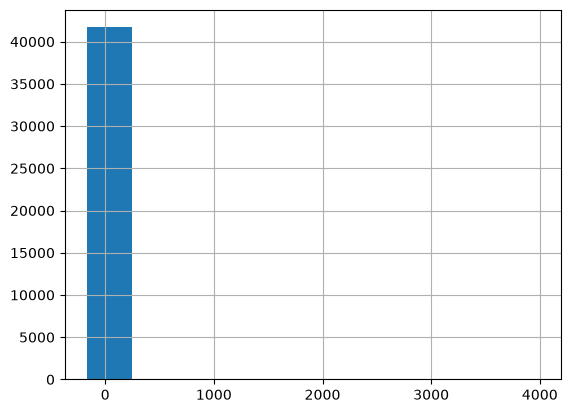

In [87]:
diff_df.difference.hist()

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

<Axes: >

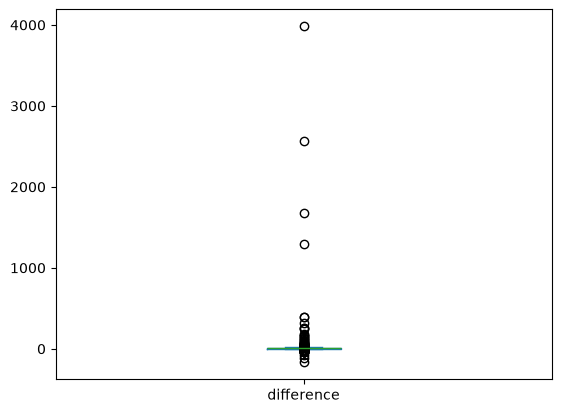

In [88]:
diff_df.difference.plot.box()

In [89]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(6.989999999999981)

In [90]:
upper_bound = Q3 + 1.5 * IQR
upper_bound
# 12.5

np.float64(17.47499999999995)

In [91]:
lower_bound = Q1 - 1.5 * IQR
lower_bound

np.float64(-10.484999999999971)

In [92]:
# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

<Axes: >

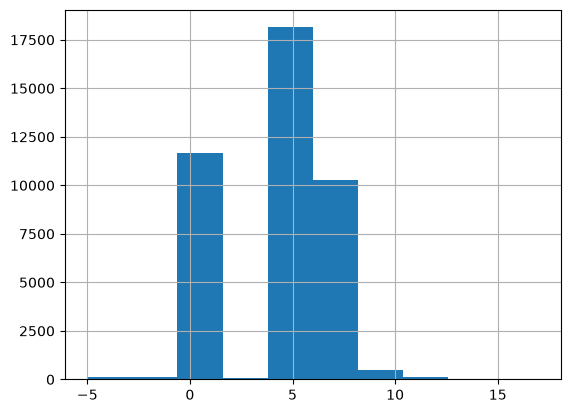

In [93]:
diff_no_outliers_df.difference.hist()

In [94]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [95]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [96]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(40985, 40985)

Products and Orderlines Merging

In [97]:
orderlines_products_price = orderlines_qu.merge(products_qu, on="sku", how="inner")[["sku", "unit_price", "price"]]

In [98]:
orderlines_products_price

,sku,unit_price,price
0,OWC0100,47.49,60.99
1,IOT0014,18.99,22.95
2,APP0700,72.19,89.00
3,CRU0039-A,60.90,76.99
4,PEB0015,142.49,299.99
...,...,...,...
53226,APP0698,9.99,25.00
53227,APP0698,9.99,25.00
53228,APP0698,9.99,25.00
53229,APP0698,9.99,25.00


In [99]:
orderlines_products_price["up_difference"] = orderlines_products_price["price"] - orderlines_products_price["unit_price"]

In [100]:
orderlines_products_price["up_difference"].mean()

np.float64(26.116673179162515)

In [101]:
orderlines_products_price["up_difference"].median()

np.float64(15.0)

In [102]:
Q1 = orderlines_products_price["up_difference"].quantile(0.25)
Q3 = orderlines_products_price["up_difference"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
print(Q3)
print(Q1)

25.749999999999996
31.0
5.2500000000000036


In [103]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-33.374999999999986
69.625


In [104]:
orderlines_products_price = (
    orderlines_qu
    .merge(products_qu, on="sku", how="inner")
    [["sku", "unit_price", "price"]]
)

orderlines_products_price["up_difference"] = (
    orderlines_products_price["price"]
    - orderlines_products_price["unit_price"]
)

print(orderlines_products_price.shape)
print(orderlines_products_price["up_difference"].describe())

(53231, 4)
count   53231.00
mean       26.12
std        45.55
min      -170.99
25%         5.25
50%        15.00
75%        31.00
max      1320.00
Name: up_difference, dtype: float64


## Is unit_price for the same SKU constant over time

In [105]:
sample_skus = orderlines_qu["sku"].sample(5, random_state=1)
# random_state=1, you get the same 5 SKUs every time 

check_df = (
    orderlines_qu.loc[orderlines_qu["sku"].isin(sample_skus), ["sku", "unit_price", "date"]]
    .merge(products_qu[["sku", "price"]], on="sku", how="left")
)

check_df.sort_values(["sku", "date"])

,sku,unit_price,date,price
0,APP0698,14.99,2017-01-01 18:25:21,25.00
1,APP0698,14.99,2017-01-02 09:54:57,25.00
2,APP0698,14.99,2017-01-02 15:10:08,25.00
4,APP0698,14.99,2017-01-03 09:40:48,25.00
6,APP0698,14.99,2017-01-03 12:30:09,25.00
7,APP0698,14.99,2017-01-03 13:49:49,25.00
10,APP0698,9.99,2017-01-05 11:59:51,25.00
11,APP0698,14.99,2017-01-05 12:14:05,25.00
12,APP0698,14.99,2017-01-05 14:22:35,25.00
13,APP0698,14.99,2017-01-05 18:12:42,25.00


In [106]:
orders_qu.to_csv("orders_qu.csv", index=False)
orderlines_qu.to_csv("orderlines_qu.csv", index=False)

In [107]:
orderprice_recent = orderlines_qu.loc[orderlines_qu.groupby("sku")["date"].idxmax(),["sku","unit_price"]]

In [108]:
orderlines_products_price = orderlines_qu.merge(products_qu, on="sku", how="inner")[["sku", "unit_price", "price"]]

In [109]:
orderprice_recent.shape

(5098, 2)

In [110]:
orderprice_recent.info()

<class 'pandas.DataFrame'>
Index: 5098 entries, 107569 to 184918
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sku         5098 non-null   str    
 1   unit_price  5098 non-null   float64
dtypes: float64(1), str(1)
memory usage: 119.5 KB


In [111]:
orderlines_products_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sku         53231 non-null  str    
 1   unit_price  53231 non-null  float64
 2   price       53231 non-null  float64
dtypes: float64(2), str(1)
memory usage: 1.2 MB


Product

In [114]:
products = pd.read_csv("../Data/not_cleaned/products.csv")

products_df= products.copy()

products_df.loc[products_df["desc"].str.contains("keyboard", case=False)]

,sku,name,desc,price,promo_price,in_stock,type
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59,589.996,0,13855401
15,MOS0021,Clearguard Moshi MacBook Pro and Air,Keyboard Protector MacBook Pro 13-inch Retina ...,24.95,249.889,0,13835403
24,APP0277,Apple Wireless Keyboard Keyboard (OEM) Mac,Ultrathin keyboard Apple Bluetooth Spanish (un...,79,759.904,0,13855401
34,TWS0019,Twelve South MagicWand support Apple Magic Tra...,MagicWand for wireless keyboard and Magic Trac...,NaN,299.899,0,8696
65,HGD0012,Henge Docks Click keyboard support iMac,Base to hold the Apple Magic TrackPad and Wire...,29,269.903,0,8696
534,LOG0084,Logitech Ultrathin Keyboard Cover Keyboard Cov...,Ultrathin cover and cover with Bluetooth keybo...,89.99,199.892,0,12575403
793,MOS0105,Moshi Clearguard CS Keyboard Protector,Transparent protective keyboard.,19.99,199.892,0,13835403
1748,LOG0144,Logitech Keys-To-Go iPad Keyboard Black,Bluetooth wireless mechanical keyboard in Span...,71.99,649.891,0,54025401
1751,LOG0156,Logitech iPad Keys-To-Go Keyboard Red,Bluetooth wireless mechanical keyboard in Span...,71.99,649.891,0,54025401
1774,LOG0148,Logitech Type + Keyboard Folio iPad Air 2 Black,Keyboard Case for iPad Air 2.,119,109.989,0,12575403


In [117]:
products_df.loc[products_df["name"].str.contains("apple iphone", case=False)]

,sku,name,desc,price,promo_price,in_stock,type
36,APP0308,AV Cable Adapter Apple iPhone iPad and iPod white,IPhone iPad iPod adapter and AV cable.,45,359.999,0,1230
376,REP0100,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,1.139.941,0,"1,44E+11"
377,REP0052,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,1.139.941,0,"1,44E+11"
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,NaN
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,NaN
798,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559,3.989.975,0,NaN
1193,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639,639.001,0,NaN
1199,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749,7.490.021,0,NaN
1200,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639,639.001,0,NaN
1201,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749,7.490.021,0,NaN


In [118]:
products_df.loc[products_df["name"].str.contains("^.{0,7}apple iphone", case=False)]

,sku,name,desc,price,promo_price,in_stock,type
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,NaN
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,NaN
798,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559,3.989.975,0,NaN
1193,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639,639.001,0,NaN
1199,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749,7.490.021,0,NaN
1200,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639,639.001,0,NaN
1201,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749,7.490.021,0,NaN
1202,APP0826,Apple iPhone 6 64GB Silver,New iPhone 6 64GB Free (MG4H2QL / A).,749,7.503.331,0,NaN
1203,APP0828,Apple iPhone 6 Plus 16GB Space Gray,New 16GB iPhone 6 Plus Free (MGA82QL / A).,749,7.490.021,0,NaN
1204,APP0832,Apple iPhone 6 Plus Case White,Ultrathin silicone case and microfiber premium.,39,389.995,0,11865403


## 3.&nbsp; One product with multiple categories
A product may fit into multiple categories. To help us create multiple categories for one product, we will use the python addition assignment `+=`. The addition assignment is a shorthand way to add something (number, string, etc...) to a variable without changing the variable name.

Let's have a look at a couple of examples.

In [120]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          19326 non-null  str  
 1   name         19326 non-null  str  
 2   desc         19319 non-null  str  
 3   price        19280 non-null  str  
 4   promo_price  19326 non-null  str  
 5   in_stock     19326 non-null  int64
 6   type         19276 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.0 MB


In [124]:
# products_cl.csv
products_cl= pd.read_csv("../Data/cleaned/products_cl.csv")

In [125]:
products_cl['sub_category'] = ""

In [126]:
products_cl["product_condition"] = "new"
products_cl.loc[
    products_cl["name"].str.contains("open|like new|second hand|abierto", case=False, na=False),
    "product_condition"
] = "refurbished"

In [127]:

# Verify
products_cl["product_condition"].value_counts()
# 1602/9992 16% refurbished products 

product_condition
new            8390
refurbished    1602
Name: count, dtype: int64

In [128]:
type_map = {
    "11865403": "iPhone/iPad Case",
    "12635403": "iPhone/iPad Case",
    "12575403": "iPhone/iPad Case",
    "12175397": "NAS / Network Storage",
    "1404": "NAS / Network Storage",
    "1280": "NAS / Network Storage",
    "11935397": "Hard Drive",
    "12655397": "Hard Drive",
    "11905404": "Smart Home / Gadgets",
    "5404": "Smart Home / Gadgets",
    "13835403": "MacBook Case",
    "5,74E+15": "Mac Desktop",
    "118692158": "Mac Desktop",
    "2,16E+11": "Mac Desktop",
    "21632158": "Mac Desktop",
    "5,43E+15": "Mac Desktop",
    "5,72E+15": "Mac Desktop",
    "1364": "RAM / Memory",
    "12585395": "Adapters / Hubs",
    "5395": "Adapters / Hubs",
    "14365395": "Adapters / Hubs",
    "1276": "Adapters / Hubs",
    "1296": "Monitor",
    "1325": "Cable",
    "1230": "Cable",
    "5384": "Headphones",
    "1433": "SSD",
    "12215397": "SSD",
    "12755395": "SSD",
    "5398": "Speaker",
    "1,02E+12": "Mac Laptop",
    "2158": "Mac Laptop",
    "5,39E+11": "Mac Laptop",
    "2,17E+11": "Mac Laptop",
    "57445397": "USB / Memory",
    "42945397": "USB / Memory",
    "1,44E+11": "Repair Service",
    "20642062": "Repair Service",
    "1334": "Networking",
    "2449": "Apple Watch Accessory",
    "24215399": "Apple Watch Accessory",
    "2434": "Apple Watch Accessory",
    "1229": "Stylus",
    "12995397": "Dock",
    "1515": "Power Bank / Charger",
    "13615399": "Power Bank / Charger",
    "5,49E+11": "Power Bank / Charger",
    "13005399": "Power Bank / Charger",
    "5399": "Power Bank / Charger",
    "1405": "Graphics Tablet",
    "101781405": "Graphics Tablet",
    "13555403": "Screen Protector",
    "14035403": "Screen Protector",
    "1216": "Mount / Stand",
    "8696": "Mount / Stand",
    "5720": "Mount / Stand",
    "12355400": "Mount / Stand",
    "24885185": "Apple Watch",
    "24895185": "Apple Watch",
    "21485407": "Replacement Part",
    "12645406": "Replacement Part",
    "14305406": "Replacement Part",
    "10142": "Replacement Part",
    "21535407": "Replacement Part",
    "1392": "Backpack",
    "10230": "Backpack",
    "11821715": "Music Player",
    "9094": "Security Camera",
    "51601716": "iPhone",
    "85651716": "iPhone",
    "85641716": "iPhone",
    "1716": "iPhone",
    "24821716": "iPhone",
    "24811716": "iPhone",
    "113281716": "iPhone",
    "113291716": "iPhone",
    "5405": "Sport Armband",
    "13855401": "Keyboard",
    "12141714": "iPad",
    "106431714": "iPad",
    "51861714": "iPad",
    "1714": "iPad",
    "51871714": "iPad",
    "13621714": "iPad",
    "42931714": "iPad",
    "24861714": "iPad",
    "1416": "Software",
    "1387": "Mouse / Trackpad",
    "5403": "Case",
    "1375": "Microphone",
    "54864259": "Remote Control",
    "4259": "Apple TV",
    "12285400": "Other",
    "12085400": "Other",
}

In [129]:
products_cl["sub_category"] = products_cl["type"].map(type_map)
products_cl["sub_category"] = products_cl["sub_category"].fillna("Other")

In [130]:
laptop_mask = (products_cl["type"] == "1282") & (products_cl["name"].str.contains("MacBook", case=False, na=False))
desktop_mask = (products_cl["type"] == "1282") & (products_cl["name"].str.contains("iMac|Mac mini|Mac Pro", case=False, na=False))

products_cl.loc[laptop_mask, "sub_category"] = "Mac Laptop"
products_cl.loc[desktop_mask, "sub_category"] = "Mac Desktop"

products_cl.loc[(products_cl["type"] == "1282") & ~laptop_mask & ~desktop_mask, "name"]

6792    Second hand - Apple LED Cinema Display 27 "Mid...
6848          Second hand - Apple LED Cinema Display 27 "
6849                        Apple LED Cinema Display 24 "
9593          Second hand - Apple LED Cinema Display 24 "
Name: name, dtype: str

In [131]:
products_cl.loc[
    (products_cl["type"] == "1282") & ~laptop_mask & ~desktop_mask,
    "sub_category"
] = "Monitor"

In [138]:
products_cl["category"] = ""

products_cl.loc[
    products_cl["desc"].str.contains("keyboard", case=False, na=False),
    "category"
] += ", keyboard"

products_cl.loc[
    products_cl["name"].str.contains(r"^.{0,7}apple iphone", case=False, na=False),
    "category"
] += ", smartphone"

products_cl.loc[
    products_cl["name"].str.contains(r"^.{0,7}apple ipod", case=False, na=False),
    "category"
] += ", ipod"

products_cl.loc[
    products_cl["name"].str.contains(r"^.{0,7}apple ipad|tablet", case=False, na=False),
    "category"
] += ", tablet"

products_cl.loc[
    products_cl["name"].str.contains("imac|mac mini|mac pro", case=False, na=False),
    "category"
] += ", desktop"

products_cl.loc[
    products_cl["name"].str.contains("macbook", case=False, na=False),
    "category"
] += ", laptop"

products_cl.loc[
    products_cl["desc"].str.contains("backpack", case=False, na=False),
    "category"
] += ", backpack"

products_cl.loc[
    products_cl["desc"].str.contains(
        "case|funda|housing|casing|folder",
        case=False,
        na=False
    ),
    "category"
] += ", case"

products_cl.loc[
    products_cl["desc"].str.contains(
        "dock|hub|connection|expansion box",
        case=False,
        na=False
    ),
    "category"
] += ", dock"

products_cl.loc[
    products_cl["desc"].str.contains(
        "cable|connector|lightning to usb|wall socket|power strip",
        case=False,
        na=False
    ),
    "category"
] += ", cable"

products_cl.loc[
    products_cl["desc"].str.contains(
        "flash drive|hard drive|pendrive|hard disk|memory|storage|^ssd|^hardssd|modules|ssd expansion",
        case=False,
        na=False
    ),
    "category"
] += ", storage"

In [141]:
products_cl.loc[
    products_cl["desc"].str.contains("battery", case=False, na=False),
    "category"
] += ", battery"

products_cl.loc[
    products_cl["desc"].str.contains("headset|headphones", case=False, na=False),
    "category"
] += ", headset"

products_cl.loc[
    products_cl["desc"].str.contains("charger", case=False, na=False),
    "category"
] += ", charger"

products_cl.loc[
    products_cl["desc"].str.contains("mouse|trackpad", case=False, na=False),
    "category"
] += ", mouse"

products_cl.loc[
    products_cl["desc"].str.contains("stand|support", case=False, na=False),
    "category"
] += ", stand"

products_cl.loc[
    products_cl["desc"].str.contains("strap|armband|belt|bracelet", case=False, na=False),
    "category"
] += ", strap"

products_cl.loc[
    products_cl["desc"].str.contains(
        r"^.{0,6}apple watch|smartwatch|smart watch",
        case=False,
        na=False
    ),
    "category"
] += ", smartwatch"

products_cl.loc[
    products_cl["desc"].str.contains("adapter", case=False, na=False),
    "category"
] += ", adapter"

products_cl.loc[
    products_cl["desc"].str.contains(r"^.{0,7}ram", case=False, na=False),
    "category"
] += ", ram"

products_cl.loc[
    products_cl["desc"].str.contains(
        "protect|cover|sleeve|screensaver|shell",
        case=False,
        na=False
    ),
    "category"
] += ", protection"

products_cl.loc[
    products_cl["desc"].str.contains(
        "nas|server|raid|synology",
        case=False,
        na=False
    ),
    "category"
] += ", server"

products_cl.loc[
    products_cl["desc"].str.contains("scale", case=False, na=False),
    "category"
] += ", scale"

products_cl.loc[
    products_cl["desc"].str.contains("thermometer", case=False, na=False),
    "category"
] += ", thermometer"

products_cl.loc[
    products_cl["desc"].str.contains("monitor", case=False, na=False),
    "category"
] += ", monitor"

products_cl.loc[
    products_cl["desc"].str.contains(
        "speaker|music system",
        case=False,
        na=False
    ),
    "category"
] += ", speaker"

products_cl.loc[
    products_cl["desc"].str.contains("camera", case=False, na=False),
    "category"
] += ", camera"

products_cl.loc[
    products_cl["desc"].str.contains("pointer", case=False, na=False),
    "category"
] += ", pointer"

products_cl.loc[
    products_cl["desc"].str.contains(
        "refurbished|reconditioned|like new",
        case=False,
        na=False
    ),
    "category"
] += ", refurbished"

In [142]:
products_cl.loc[
    products_cl["category"] == "",
    "category"
] = ", other"

In [143]:
products_cl[["name", "desc", "category"]].head(20)

,name,desc,category
0,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,", stand"
1,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,", keyboard"
2,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,", cable, mouse"
3,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,", dock, cable"
4,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,", ram"
5,Apple Composite AV Cable iPhone and iPod white,IPhone and iPod AV Cable Dock to Composite Video.,", dock, cable"
6,Mac Memory Kingston 1GB 667MHz DDR2 SO-DIMM,1GB RAM Mac mini and iMac (2006/07) MacBook Pr...,", ram"
7,Mac Memory Kingston 2GB 800MHz DDR2 SO-DIMM,2GB RAM iMac with Intel Core 2 Duo (Penryn).,", ram"
8,Mac memory Kingston 4GB (2x2GB) 667MHz DDR2 SO...,RAM 4GB (2x2GB) Mac mini and iMac (2006/07) Ma...,", ram"
9,Apple Adapter Mini Display Port to VGA,Adapter Mini Display Port to VGA MacBook and M...,", adapter"


In [144]:
products_cl["category"].value_counts()

category
, other                                         1150
, desktop                                        714
, storage                                        636
, server                                         589
, laptop                                         546
, protection                                     540
, case                                           532
, storage, server                                354
, cable                                          227
, case, protection                               187
, monitor                                        178
, ram                                            177
, tablet                                         177
, adapter                                        175
, strap                                          171
, refurbished                                    159
, dock                                           148
, smartphone                                     142
, speaker                            

In [146]:
products_cl["category"] = products_cl["category"].str[2:]

products_cl["category"].value_counts()

category
other                                         1150
desktop                                        714
storage                                        636
server                                         589
laptop                                         546
protection                                     540
case                                           532
storage, server                                354
cable                                          227
case, protection                               187
monitor                                        178
ram                                            177
tablet                                         177
adapter                                        175
strap                                          171
refurbished                                    159
dock                                           148
smartphone                                     142
speaker                                        128
headset               

## 4.&nbsp; [BONUS] Using `type` to create categories
There could be another way to create categories, but this one you'll have to explore this one alone.

We have the mysterious column `type` in the `products` table. This could potentially be ready-made categories labelled with numbers instead of words. Let's investigate.

In [147]:
category_type_df = products_cl.copy()

In [148]:
category_type_df.groupby("type").count().nlargest(10, "sku")

,sku,name,desc,price,in_stock,sub_category,product_condition,category
type,,,,,,,,
11865403,1057,1057,1057,1057,1057,1057,1057,1057
12175397,939,939,939,939,939,939,939,939
1298,783,783,783,783,783,783,783,783
11935397,562,562,562,562,562,562,562,562
11905404,454,454,454,454,454,454,454,454
1282,373,373,373,373,373,373,373,373
12635403,362,362,362,362,362,362,362,362
13835403,269,269,269,269,269,269,269,269
"5,74E+15",247,247,247,247,247,247,247,247


In [149]:
category_type_df.loc[category_type_df["type"] == "11865403"].sample(10)

,sku,name,desc,price,in_stock,type,sub_category,product_condition,category
3954,HIC0020,Hitcase Snap lens cover and arm support iPhone...,rigid case with wide angle lens and extensible...,89.99,0,11865403,iPhone/iPad Case,new,"case, stand"
9041,EVU0013,Evutec Aergo Ballistic Nylon Case + Support Ha...,Protection cover with plastic anti-impact nylo...,29.99,1,11865403,iPhone/iPad Case,new,protection
8402,APP2535,Apple iPhone leather case Leather Case 8 Plus ...,ultrathin leather case and microfibre premium ...,59.00,0,11865403,iPhone/iPad Case,new,"smartphone, case"
4450,MAC0135,PC Macally iPhone case Case SE / 5s / 5 Black,Protective Case for iPhone SE / 5s / 5,9.95,0,11865403,iPhone/iPad Case,new,"case, protection"
9414,OTT0170-A,Open - Otterbox Clearly Protected Gel Case iPh...,Reconditioned transparent sleeve one-piece and...,19.99,0,11865403,iPhone/iPad Case,refurbished,"protection, refurbished"
5336,BEL0275,Belkin SheerForce Air Protect Case Black iPhon...,Case technology against impact and wear resist...,19.99,0,11865403,iPhone/iPad Case,new,case
3156,SNA0058,Sena UltraSlim Case Heritage iPhone 6 / 6S / 7...,ultra thin skin iPhone 6 / 6s and 7 Case,39.95,0,11865403,iPhone/iPad Case,new,case
5325,BEL0294,Belkin SheerForce Air Protect Case iPhone 6 / ...,Cover with compact design and wear resistant m...,19.99,0,11865403,iPhone/iPad Case,new,protection
5433,MUJ0018,Mujjo iPhone Leather Case Leather Champagne 8/7/6,ultrathin Case for iPhone vegetable tanned lea...,39.90,1,11865403,iPhone/iPad Case,new,case
2549,BEL0184,Belkin Folio Case Classic iPhone 6 / 6S Blue,protective case with microfiber interior for i...,29.90,0,11865403,iPhone/iPad Case,new,"case, protection"


Looks like this is a category of phone cases.

Let's have a look at the 2nd largest type to see if that's also a clear category.

In [150]:
category_type_df.loc[category_type_df["type"] == "12175397"].sample(10)

,sku,name,desc,price,in_stock,type,sub_category,product_condition,category
5951,PAC1767,QNAP TS-431P NAS,NAS with 40TB capacity Seagate Hard Drives for...,1901.95,0,12175397,NAS / Network Storage,new,"storage, server"
8815,PAC2459,DS218J Synology NAS Server | 16TB (2x8TB) Seag...,2-bay NAS server entry-level to back domestic ...,905.97,1,12175397,NAS / Network Storage,new,server
8574,PAC2340,Synology DS718 + NAS Server | 10GB RAM | 20TB ...,Scalable NAS server with transcoding 4K: 4-cor...,1351.33,0,12175397,NAS / Network Storage,new,server
8844,PAC2475,Synology DS118 NAS Server | 12TB (1x12TB) Seag...,1 bay NAS server with capacity for home use or...,675.98,0,12175397,NAS / Network Storage,new,server
8647,PAC2428,Synology DS918 + NAS Server | 8GB RAM,NAS server of the Plus Series for companies se...,636.98,0,12175397,NAS / Network Storage,new,"storage, server, scale"
4406,PAC1416,Synology DS716 + II Pack | 8GB RAM | WD 8TB Ne...,Synology DS716 + II with 8GB of RAM memory + 8...,889.89,0,12175397,NAS / Network Storage,new,"storage, server"
1271,PAC0590,Synology DS415 + Pack | WD 24TB Network,Synology DS415 + Pack of 24TB WD Network for M...,1770.99,0,12175397,NAS / Network Storage,new,server
5969,QNA0193,QNAP TS-863U-RP NAS Server | 4GB RAM,8-bay NAS rack format includes a port 10GbE tr...,1910.59,0,12175397,NAS / Network Storage,new,server
7077,PAC2306,Synology DS1817 + | 2GB RAM | 80TB (8x10TB) WD...,NAS server with 2GB of RAM and 80TB for Mac an...,4490.89,0,12175397,NAS / Network Storage,new,server
922,PAC0481,Synology DS415 Pack play | Seagate 16TB,Synology DS415 + Pack 16TB play Seagate Deskto...,941.59,0,12175397,NAS / Network Storage,new,server


In [152]:
category_type_df["type"].sample(20)

8811     12175397
4519     51601716
5821         5720
9873         1515
230      1,44E+11
694      11905404
7554     2,16E+11
5505         5384
1273     11935397
4337         1296
5662         2158
1106     11865403
8732     11865403
3421     12175397
4199     12635403
5390     24885185
9434         5401
8210    113291716
8990         5384
8426         1298
Name: type, dtype: str